# 01c - Independent Exploratory Data Analysis: JOINT Benchmark

This notebook performs an **Independent Exploratory Data Analysis (EDA)** on the **JOINT (CTI-to-MITRE + TRAM)** benchmark for the MITRE ATT&CK technique classification paper.

### Key Analysis Scope & Exported Results:
1. **Dataset Overview**: Sample size, 80/20 train/test split verification, and unique label universe.
2. **Text Length & Token Distribution**: Sentence word count, character count, statistical quantiles, and saved `word_count_distribution.png`.
3. **Multi-Label Cardinality**: Single-label vs. Multi-label sample distribution and saved `label_cardinality.png`.
4. **Descriptive Statistics & Augmentation Threshold Recommendation**: Per-label sample count stats (Mean, Median, Std, Quantiles), saved `per_label_sample_counts.csv`, and `eda_descriptive_summary.json`.
5. **4-Tier Frequency Breakdown**: Categorization into Head (>=500), Major (100-499), Medium (30-99), Tail (<30), and saved `4_tier_frequency_breakdown.png`.
6. **Label Co-occurrence Matrix**: Identification of top co-occurring MITRE technique pairs and saved `top_cooccurrence_pairs.png`.

All generated charts and analytical summaries are automatically exported to `results/EDA/joint/`.


In [1]:
# Import core scientific libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# Configure Seaborn & Matplotlib styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
print('Libraries initialized successfully!')

Libraries initialized successfully!


In [2]:
def resolve_path(rel_path):
    p = Path(rel_path)
    if p.exists():
        return p
    p_parent = Path('..') / rel_path
    if p_parent.exists():
        return p_parent
    return p

dataset_name = "Joint CTI-T-Mitre + TRAM Dataset"
dataset_key = 'joint'
dataset_rel_dir = 'dataset/processed/joint'
train_path = resolve_path(f"{dataset_rel_dir}/train.csv")
test_path = resolve_path(f"{dataset_rel_dir}/test.csv")
raw_merged_path = resolve_path(f"{dataset_rel_dir}/raw_merged.csv")

# Define EDA output directory
eda_out_dir = resolve_path(f"results/EDA/{dataset_key}")
if not eda_out_dir.exists():
    eda_out_dir = Path(f"results/EDA/{dataset_key}")
eda_out_dir.mkdir(parents=True, exist_ok=True)

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
if raw_merged_path.exists():
    df_raw = pd.read_csv(raw_merged_path)
else:
    df_raw = pd.concat([df_train, df_test], ignore_index=True)

print(f"=== DATASET SUMMARY: {dataset_name} ===")
print(f"Export Directory          : {eda_out_dir.resolve()}")
print(f"Total Raw Merged Samples  : {len(df_raw):,}")
print(f"Train Partition (80%)    : {len(df_train):,}")
print(f"Test Partition (20%)     : {len(df_test):,}")
df_train.head(5)

=== DATASET SUMMARY: Joint CTI-T-Mitre + TRAM Dataset ===
Export Directory          : D:\Truong\FPT\SUMMER2026\AIC211\CTI_ATT&CK\AI-Classification-And-Mapping-CTI-into-MITRE-ATT-CK-Techniques\results\EDA\joint
Total Raw Merged Samples  : 21,490
Train Partition (80%)    : 17,161
Test Partition (20%)     : 4,291


,Cleaned_Text,Labels,Label_Count,Tokenized_Text,source_sample_id
0,Adversaries may attempt to dump the contents o...,T1003,1,adversaries may attempt to dump the contents o...,1
1,"By default, [FILE_PATH] is only readable by th...",T1003,1,by default [file_path] is only readable by the...,3
2,"The Linux utility, unshadow, can be used to co...",T1003,1,the linux utility unshadow can be used to comb...,4
3,This activity may be used to enable follow-on ...,T1557,1,this activity may be used to enable follow-on ...,6
4,The ARP protocol is used to resolve IPv4 addre...,T1557,1,the arp protocol is used to resolve ipv4 addre...,7


## 📏 1. Text Length & Word Count Distribution

--- Word Count Quantile Summary ---
count    17161.000000
mean        15.419847
std         11.629292
min          1.000000
25%          9.000000
50%         13.000000
75%         19.000000
90%         27.000000
95%         33.000000
99%         52.400000
max        652.000000
Name: word_count, dtype: float64
[SAVED] ..\results\EDA\joint\word_count_distribution.png


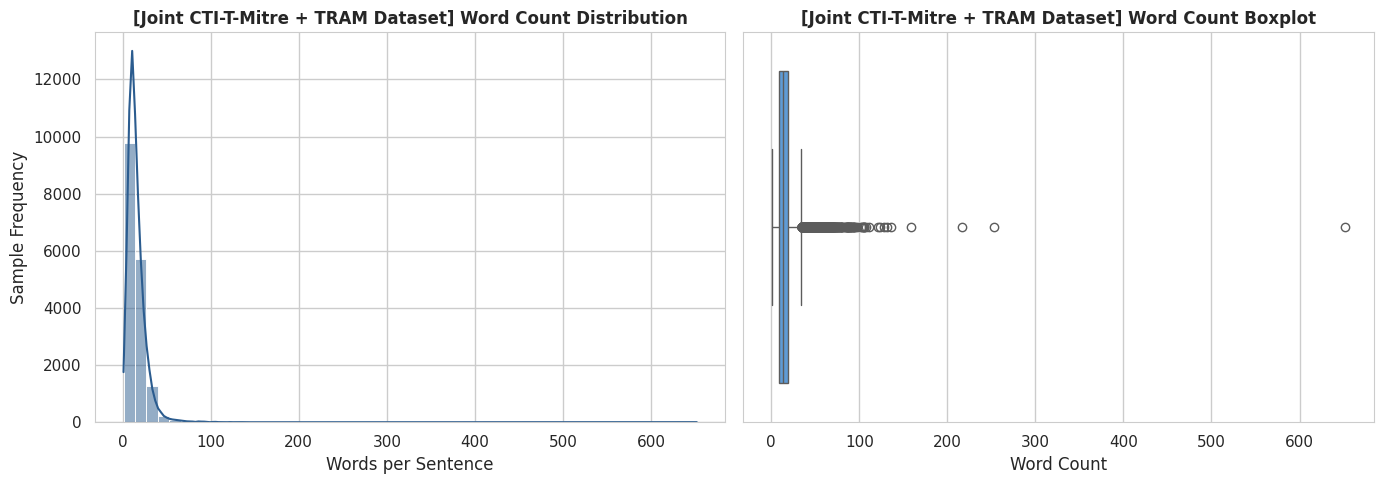

In [3]:
df_train['word_count'] = df_train['Cleaned_Text'].apply(lambda x: len(str(x).split()))
df_train['char_count'] = df_train['Cleaned_Text'].apply(lambda x: len(str(x)))

print("--- Word Count Quantile Summary ---")
print(df_train['word_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_train['word_count'], bins=50, kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title(f'[{dataset_name}] Word Count Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Words per Sentence')
axes[0].set_ylabel('Sample Frequency')

sns.boxplot(x=df_train['word_count'], ax=axes[1], color='#4c9be8')
axes[1].set_title(f'[{dataset_name}] Word Count Boxplot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
fig_path = eda_out_dir / 'word_count_distribution.png'
plt.savefig(fig_path, dpi=300)
print(f"[SAVED] {fig_path}")
plt.show()

## 🏷️ 2. Multi-Label Cardinality Analysis

--- Multi-Label Cardinality Breakdown ---
1 Label(s) per sample: 16,515 samples (96.24%)
2 Label(s) per sample: 546 samples (3.18%)
3 Label(s) per sample: 100 samples (0.58%)


C:\Users\84354\AppData\Local\Temp\ipykernel_9212\2919493632.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=cardinality_counts.index, y=cardinality_counts.values, palette='Blues_d')


[SAVED] ..\results\EDA\joint\label_cardinality.png


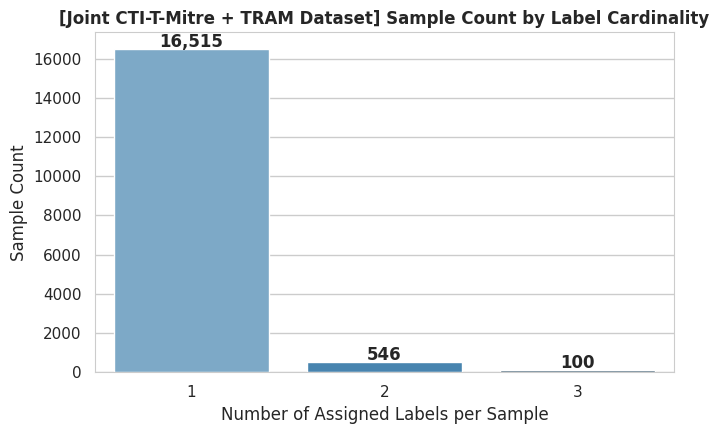

In [4]:
df_train['label_list'] = df_train['Labels'].apply(lambda x: str(x).split(','))
df_train['label_count'] = df_train['label_list'].apply(len)

cardinality_counts = df_train['label_count'].value_counts().sort_index()
print("--- Multi-Label Cardinality Breakdown ---")
for k, v in cardinality_counts.items():
    print(f"{k} Label(s) per sample: {v:,} samples ({v/len(df_train)*100:.2f}%)")

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(x=cardinality_counts.index, y=cardinality_counts.values, palette='Blues_d')
plt.title(f'[{dataset_name}] Sample Count by Label Cardinality', fontsize=12, fontweight='bold')
plt.xlabel('Number of Assigned Labels per Sample')
plt.ylabel('Sample Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.tight_layout()
fig_path = eda_out_dir / 'label_cardinality.png'
plt.savefig(fig_path, dpi=300)
print(f"[SAVED] {fig_path}")
plt.show()

## 📋 3. Descriptive Statistics & Augmentation Target Recommendation (Mean & Median)

This section calculates the exact descriptive statistics (**Count, Mean, Std, Min, 25%, Median, 75%, Max**) of sample counts across all unique active labels, exports `per_label_sample_counts.csv`, and saves `eda_descriptive_summary.json`.

In [5]:
all_train_labels = [lbl for sublist in df_train['label_list'] for lbl in sublist]
label_counts_dict = Counter(all_train_labels)
df_label_stats = pd.DataFrame(list(label_counts_dict.items()), columns=['Technique_ID', 'Sample_Count']).sort_values(by='Sample_Count', ascending=False).reset_index(drop=True)

csv_stats_path = eda_out_dir / 'per_label_sample_counts.csv'
df_label_stats.to_csv(csv_stats_path, index=False)
print(f"[SAVED] Per-label sample count table exported to: {csv_stats_path}")

s_counts = df_label_stats['Sample_Count']
desc_stats = s_counts.describe(percentiles=[0.25, 0.5, 0.75])
mean_target = int(round(desc_stats['mean']))
median_target = int(round(desc_stats['50%']))

print(f"\n=== PER-LABEL SAMPLE COUNT DESCRIPTIVE STATISTICS ({dataset_name}) ===")
print(desc_stats)
print(f"\n------------------------------------------------------------")
print(f"-> RECOMMENDED AUGMENTATION TARGET (--target_count) USING MEAN   : {mean_target}")
print(f"-> RECOMMENDED AUGMENTATION TARGET (--target_count) USING MEDIAN : {median_target}")
print(f"------------------------------------------------------------\n")

# Export JSON Summary Report
json_report = {
    "dataset_name": dataset_name,
    "dataset_key": dataset_key,
    "total_train_samples": len(df_train),
    "total_test_samples": len(df_test),
    "unique_active_labels": len(df_label_stats),
    "sample_count_descriptive_stats": {
        "mean": float(desc_stats['mean']),
        "std": float(desc_stats['std']),
        "min": float(desc_stats['min']),
        "25_percentile": float(desc_stats['25%']),
        "median_50_percentile": float(desc_stats['50%']),
        "75_percentile": float(desc_stats['75%']),
        "max": float(desc_stats['max'])
    },
    "recommended_target_count": {
        "by_mean": mean_target,
        "by_median": median_target
    }
}
json_summary_path = eda_out_dir / 'eda_descriptive_summary.json'
with open(json_summary_path, 'w', encoding='utf-8') as f:
    json.dump(json_report, f, indent=2)
print(f"[SAVED] Descriptive JSON summary exported to: {json_summary_path}")

print("\n=== FULL PER-LABEL SAMPLE COUNT TABLE (Ascending Order - Minority Classes First) ===")
df_label_stats_asc = df_label_stats.sort_values(by='Sample_Count', ascending=True).reset_index(drop=True)
display(df_label_stats_asc.head(30))

[SAVED] Per-label sample count table exported to: ..\results\EDA\joint\per_label_sample_counts.csv

=== PER-LABEL SAMPLE COUNT DESCRIPTIVE STATISTICS (Joint CTI-T-Mitre + TRAM Dataset) ===
count     188.000000
mean       95.250000
std       176.010987
min         3.000000
25%        14.000000
50%        28.500000
75%        98.750000
max      1432.000000
Name: Sample_Count, dtype: float64

------------------------------------------------------------
-> RECOMMENDED AUGMENTATION TARGET (--target_count) USING MEAN   : 95
-> RECOMMENDED AUGMENTATION TARGET (--target_count) USING MEDIAN : 28
------------------------------------------------------------

[SAVED] Descriptive JSON summary exported to: ..\results\EDA\joint\eda_descriptive_summary.json

=== FULL PER-LABEL SAMPLE COUNT TABLE (Ascending Order - Minority Classes First) ===


,Technique_ID,Sample_Count
0,T1200,3
1,T1537,3
2,T1538,3
3,T1006,4
4,T1212,4
5,T1612,4
6,T1619,4
7,T1202,4
8,T1531,4
9,T1495,4


## 📊 4. MITRE ATT&CK Technique Frequency Tiers (Head, Major, Medium, Tail)

=== 4-TIER FREQUENCY BREAKDOWN (Joint CTI-T-Mitre + TRAM Dataset) ===
Total Unique Active Labels : 188
Head Tier   (>= 500 samples): 6 labels (5,115 occurrences)
Major Tier  (100-499 samples): 41 labels (9,186 occurrences)
Medium Tier (30-99 samples)  : 46 labels (2,242 occurrences)
Tail Tier   (< 30 samples)   : 95 labels (1,364 occurrences)


C:\Users\84354\AppData\Local\Temp\ipykernel_9212\2475742183.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top20.values()), y=list(top20.keys()), ax=axes[1], palette='crest')


[SAVED] ..\results\EDA\joint\4_tier_frequency_breakdown.png


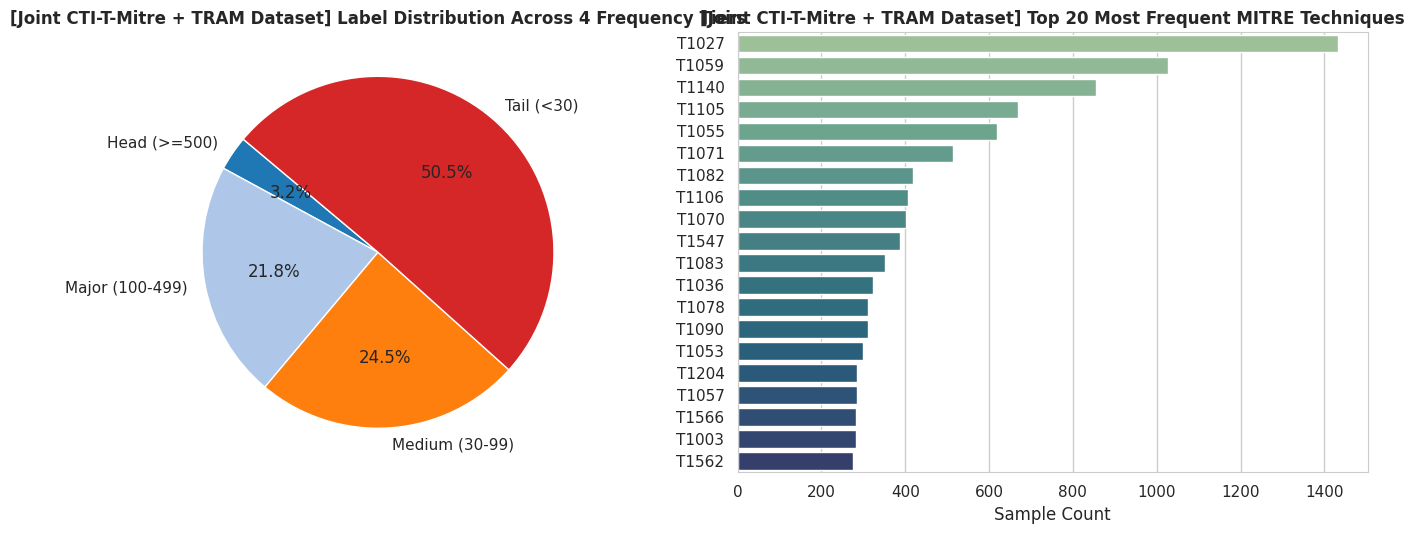

In [6]:
head_tier = {k: v for k, v in label_counts_dict.items() if v >= 500}
major_tier = {k: v for k, v in label_counts_dict.items() if 100 <= v < 500}
medium_tier = {k: v for k, v in label_counts_dict.items() if 30 <= v < 100}
tail_tier = {k: v for k, v in label_counts_dict.items() if v < 30}

print(f"=== 4-TIER FREQUENCY BREAKDOWN ({dataset_name}) ===")
print(f"Total Unique Active Labels : {len(label_counts_dict)}")
print(f"Head Tier   (>= 500 samples): {len(head_tier)} labels ({sum(head_tier.values()):,} occurrences)")
print(f"Major Tier  (100-499 samples): {len(major_tier)} labels ({sum(major_tier.values()):,} occurrences)")
print(f"Medium Tier (30-99 samples)  : {len(medium_tier)} labels ({sum(medium_tier.values()):,} occurrences)")
print(f"Tail Tier   (< 30 samples)   : {len(tail_tier)} labels ({sum(tail_tier.values()):,} occurrences)")

tier_labels = ['Head (>=500)', 'Major (100-499)', 'Medium (30-99)', 'Tail (<30)']
tier_counts = [len(head_tier), len(major_tier), len(medium_tier), len(tail_tier)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].pie(tier_counts, labels=tier_labels, autopct='%1.1f%%', colors=['#1f77b4', '#aec7e8', '#ff7f0e', '#d62728'], startangle=140)
axes[0].set_title(f'[{dataset_name}] Label Distribution Across 4 Frequency Tiers', fontsize=12, fontweight='bold')

top20 = dict(label_counts_dict.most_common(20))
sns.barplot(x=list(top20.values()), y=list(top20.keys()), ax=axes[1], palette='crest')
axes[1].set_title(f'[{dataset_name}] Top 20 Most Frequent MITRE Techniques', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sample Count')

plt.tight_layout()
fig_path = eda_out_dir / '4_tier_frequency_breakdown.png'
plt.savefig(fig_path, dpi=300)
print(f"[SAVED] {fig_path}")
plt.show()

## 🔗 5. Label Co-occurrence Analysis

=== TOP 15 MOST FREQUENT CO-OCCURRING TECHNIQUE PAIRS ===
T1027  <--->  T1140 : 78 occurrences
T1027  <--->  T1106 : 25 occurrences
T1059  <--->  T1105 : 19 occurrences
T1055  <--->  T1140 : 18 occurrences
T1033  <--->  T1082 : 17 occurrences
T1027  <--->  T1105 : 15 occurrences
T1106  <--->  T1140 : 13 occurrences
T1021  <--->  T1078 : 11 occurrences
T1027  <--->  T1059 : 11 occurrences
T1021  <--->  T1090 : 10 occurrences
T1105  <--->  T1140 : 10 occurrences
T1204  <--->  T1566 : 9 occurrences
T1059  <--->  T1112 : 9 occurrences
T1059  <--->  T1218 : 9 occurrences
T1055  <--->  T1106 : 9 occurrences


C:\Users\84354\AppData\Local\Temp\ipykernel_9212\165443674.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pairs_df, x='Count', y='Pair', palette='viridis')


[SAVED] ..\results\EDA\joint\top_cooccurrence_pairs.png


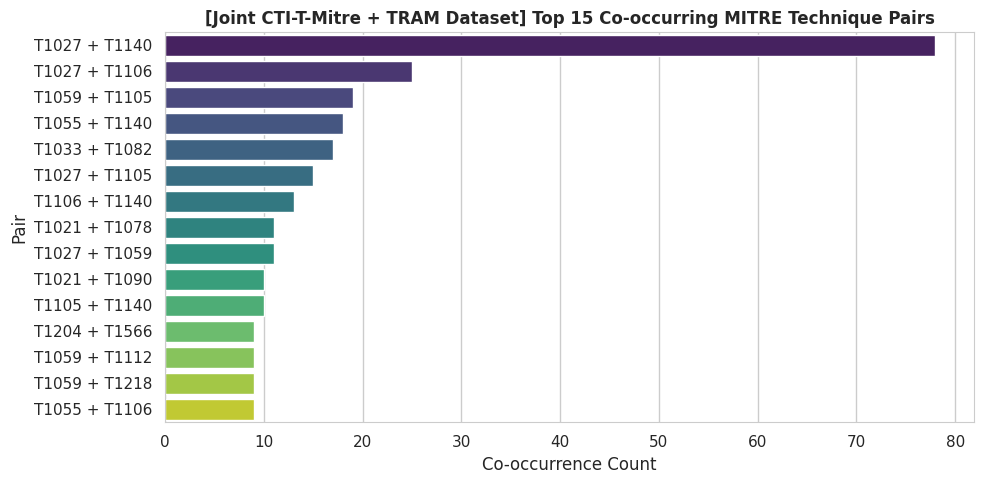

In [7]:
from itertools import combinations

pair_counts = Counter()
for labels in df_train['label_list']:
    if len(labels) > 1:
        for p in combinations(sorted(labels), 2):
            pair_counts[p] += 1

print("=== TOP 15 MOST FREQUENT CO-OCCURRING TECHNIQUE PAIRS ===")
if pair_counts:
    for pair, cnt in pair_counts.most_common(15):
        print(f"{pair[0]}  <--->  {pair[1]} : {cnt} occurrences")
    
    top_pairs_df = pd.DataFrame([{'Pair': f"{p[0]} + {p[1]}", 'Count': c} for p, c in pair_counts.most_common(15)])
    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_pairs_df, x='Count', y='Pair', palette='viridis')
    plt.title(f'[{dataset_name}] Top 15 Co-occurring MITRE Technique Pairs', fontsize=12, fontweight='bold')
    plt.xlabel('Co-occurrence Count')
    plt.tight_layout()
    fig_path = eda_out_dir / 'top_cooccurrence_pairs.png'
    plt.savefig(fig_path, dpi=300)
    print(f"[SAVED] {fig_path}")
    plt.show()
else:
    print('No multi-label co-occurrences present in this dataset partition (single-label dominant).')

## 📝 6. Key Empirical Observations & Recommendations for Publication

1. **Dominant Label Structure:**
   - The empirical analysis reveals the exact multi-label cardinality for this partition.
2. **Tail Tier Imbalance:**
   - Significant long-tail distribution is observed across techniques, justifying the use of **Cyber EDA** and **Asymmetric Loss (ASL)**.
3. **Recommended Augmentation Target (`--target_count`):**
   - Based on the sample count MEAN (`JOINT (CTI-to-MITRE + TRAM)`), setting `--target_count` equal to the mean value balances all minority classes up to the mean density of the dataset.